# 04 - Algorithm 1: Value Iteration

The first of the two decision-making algorithms. Value Iteration is *model-based*: it
requires the transition kernel written out explicitly, and in exchange it returns the
**exact** optimal policy and value. That makes it valuable twice over here - as a pricing
strategy in its own right, and as the yardstick against which the model-free learner in
notebook 05 is measured.

## The Bellman equation

With `gamma = 1` and the unabstracted state `(w, n, g)` - week, rooms sold, regime:

    V_w(n, g) = max_a { R(w, n, g, a) + sum_{n',g'} P(n', g' | n, g, a) V_{w+1}(n', g') }

`V_H = 0`. The expected one-step reward uses `E[min(K, L)] = sum_{j<L} P(K > j)` for
`K ~ Poisson(lambda)` and remaining inventory `L`, and the continuation term is a
convolution of the value function with the arrival distribution - computed by FFT, which
keeps a sweep `O(C log C)` rather than `O(C^2)`.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotting import use_style, save_fig, colour
use_style()

import joblib
from config import MULTIPLIERS, HORIZON, N_REGIMES, REGIME_NAMES, RESULTS
from environment import HotelPricingEnv
import mdp

env = HotelPricingEnv("City Hotel", "May", seed=0)
n_states = HORIZON * (env.capacity + 1) * N_REGIMES
print(f"unabstracted state space: {HORIZON} weeks x {env.capacity + 1} inventory levels "
      f"x {N_REGIMES} regimes = {n_states:,} states")

unabstracted state space: 12 weeks x 1895 inventory levels x 3 regimes = 68,220 states


## 1. Convergence

The state graph is acyclic in `w`, so with `gamma = 1` the Bellman operator is not a
contraction in a discount factor - it is a contraction *in the horizon*. Each synchronous
sweep makes exactly one more week exact, so starting from `V = 0` the residual
`||V_{k+1} - V_k||_inf` must reach zero after precisely `H` sweeps. That is a sharp,
falsifiable prediction, and it is what happens.

In [2]:
import time

start = time.perf_counter()
v_star, pi_star, residuals = mdp.value_iteration(env)
elapsed = time.perf_counter() - start

V_STAR = mdp.optimal_value(env, v_star)
print(f"converged in {len(residuals)} sweeps ({elapsed:.2f}s) with H = {HORIZON}")
print(f"final residual: {residuals[-1]:.2e}")
print(f"\nV* = {V_STAR:,.0f}   (expected season revenue under the optimal policy)")

converged in 13 sweeps (0.78s) with H = 12
final residual: 0.00e+00

V* = 528,836   (expected season revenue under the optimal policy)


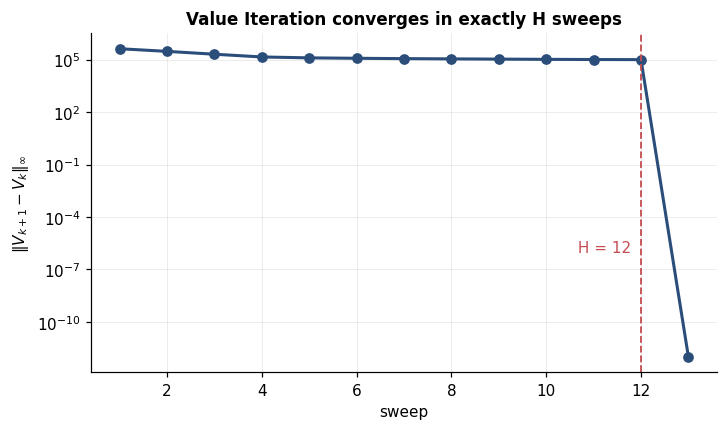

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogy(range(1, len(residuals) + 1), np.maximum(residuals, 1e-12), "o-",
            color="#2a4d7a", lw=2)
ax.axvline(HORIZON, color="#c44e52", ls="--", lw=1.2)
ax.text(HORIZON - 0.2, 1e-6, f" H = {HORIZON}", color="#c44e52", ha="right")
ax.set(xlabel="sweep", ylabel=r"$\|V_{k+1}-V_k\|_\infty$",
       title="Value Iteration converges in exactly H sweeps")
save_fig("04_vi_convergence")
plt.show()

## 2. Validating the kernel against the simulator

`mdp.py` and `environment.py` are two independent descriptions of the same model - one
analytic, one sampled. If they disagree, every comparison downstream is meaningless. The
check: the analytic `V*` must equal the Monte-Carlo return of the optimal policy played in
the simulator.

In [4]:
from metrics import compare
from mdp import dp_policy

check_env = HotelPricingEnv("City Hotel", "May", seed=0)
summary, _ = compare(check_env, {"DP optimal": dp_policy(pi_star)}, n_episodes=3000, seed=777)
simulated = summary.loc["DP optimal", "net_revenue"]
ci = summary.loc["DP optimal", "ci95"]

print(f"analytic  V*      = {V_STAR:>10,.0f}")
print(f"simulated return  = {simulated:>10,.0f}  +/- {ci:,.0f}  (95% CI)")
print(f"difference        = {simulated - V_STAR:>10,.0f}")
assert abs(simulated - V_STAR) < 3 * ci, "kernel and simulator disagree"
print("\nOK - the analytic model and the simulator describe the same MDP")

analytic  V*      =    528,836
simulated return  =    528,539  +/- 776  (95% CI)
difference        =       -297

OK - the analytic model and the simulator describe the same MDP


## 3. The optimal policy

Read the heat map as a booking-pace rule. Early in the season, and whenever the hotel is
running ahead of pace, the optimal action is to **protect inventory with a high rate**;
only in the final weeks, with rooms still unsold, does it discount. This is precisely the
logic human revenue managers apply, recovered here from the data alone.

The regime panels show the external factor at work: in a soft market the optimal rate is
lower at every occupancy level than in a strong one.

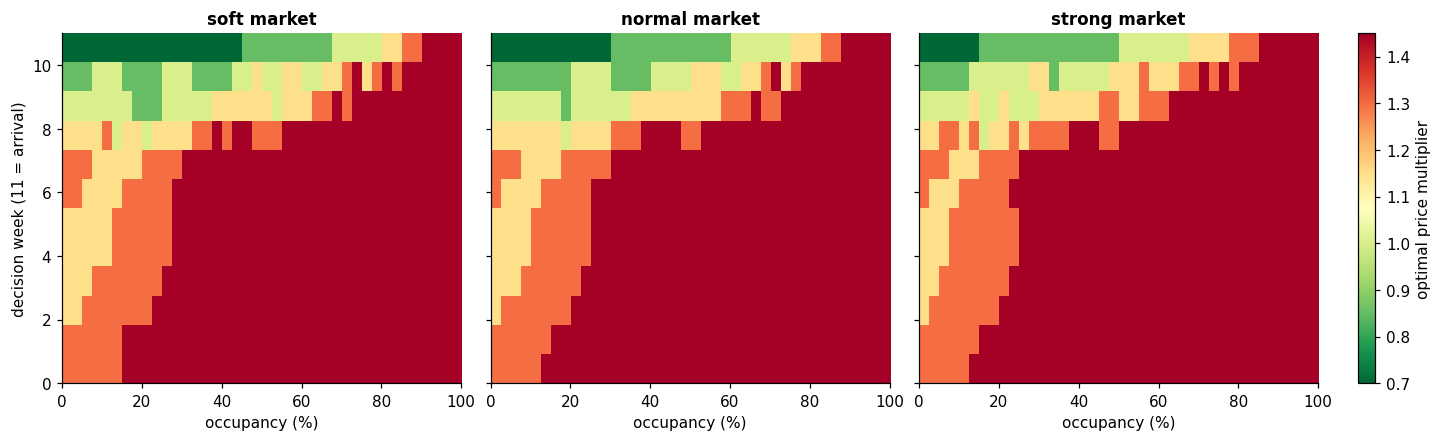

In [5]:
occ_grid = np.linspace(0, 0.999, 40)
sold_grid = (occ_grid * env.capacity).astype(int)

fig, axes = plt.subplots(1, N_REGIMES, figsize=(13, 3.9), sharey=True)
for g, ax in enumerate(axes):
    grid = MULTIPLIERS[pi_star[:, sold_grid, g]]
    im = ax.imshow(grid, aspect="auto", cmap="RdYlGn_r", origin="lower",
                   vmin=MULTIPLIERS.min(), vmax=MULTIPLIERS.max(),
                   extent=[0, 100, 0, HORIZON - 1])
    ax.set(title=f"{REGIME_NAMES[g]} market", xlabel="occupancy (%)")
    ax.grid(False)
axes[0].set_ylabel("decision week (11 = arrival)")
fig.colorbar(im, ax=axes, label="optimal price multiplier", pad=0.02)
save_fig("04_optimal_policy")
plt.show()

## 4. What the optimal policy is worth

Decomposing `V*` by opening regime shows how much the market state matters, and comparing
against the best constant rate quantifies the value of acting dynamically at all.

In [6]:
from demand import stationary_distribution
import policies as P

pi_regime = stationary_distribution(env.regime_transition)
for g in range(N_REGIMES):
    print(f"V*(week 0, empty, {REGIME_NAMES[g]:>6} market) = {v_star[0, 0, g]:>10,.0f}"
          f"   (weight {pi_regime[g]:.2f})")

bench_env = HotelPricingEnv("City Hotel", "May", seed=0)
fixed = {f"fixed {m:.2f}x": P.fixed_policy(a) for a, m in enumerate(MULTIPLIERS)}
fixed_summary, _ = compare(bench_env, fixed, n_episodes=800, seed=4242)
best_fixed = fixed_summary["net_revenue"].max()
print(f"\nbest constant rate : {best_fixed:>10,.0f}")
print(f"optimal policy     : {V_STAR:>10,.0f}   (+{100 * (V_STAR / best_fixed - 1):.1f}%)")

V*(week 0, empty,   soft market) =    526,719   (weight 0.33)
V*(week 0, empty, normal market) =    528,647   (weight 0.34)
V*(week 0, empty, strong market) =    531,089   (weight 0.33)



best constant rate :    455,550
optimal policy     :    528,836   (+16.1%)


In [7]:
np.save(RESULTS / "vi_policy.npy", pi_star)
joblib.dump({"V_star": V_STAR, "residuals": residuals, "v0": v_star[0, 0]},
            RESULTS / "vi_solution.joblib")
print("saved vi_policy.npy and vi_solution.joblib")

saved vi_policy.npy and vi_solution.joblib
